# ***Système Intelligent de Prédiction du Diabète***

# Smart Diabetes AI

## Système Intelligent de Prédiction du Diabète utilisant :
- Web Scraping (BeautifulSoup)
- Data Cleaning
- EDA
- ANN (Artificial Neural Network)
- Flask API
- React Frontend

Réalisé par :

Yassine Rachid & Jassir Matallah

# PARTIE I — SCIENCE DES DONNÉES

# Étape 1 — Importation des bibliothèques


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import requests
from bs4 import BeautifulSoup

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import pickle

import warnings
warnings.filterwarnings("ignore")

##Chargement du dataset

In [ ]:
df = pd.read_csv('/content/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Taille du dataset

In [ ]:
print("Nombre lignes :",df.shape[0])

print("Nombre colonnes :",df.shape[1])

Nombre lignes : 768
Nombre colonnes : 9


Informations générales

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Statistiques descriptives

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Web Scraping avec BeautifulSoup

In [ ]:
url="https://www.diabetes.org/healthy-living"

headers={

'User-Agent':
'Mozilla/5.0'

}

response=requests.get(
    url,
    headers=headers
)

soup=BeautifulSoup(
    response.text,
    "html.parser"
)

titles=[]
descriptions=[]

for article in soup.find_all("h2")[:15]:

    title=article.get_text(
        strip=True
    )

    titles.append(
        title
    )

titles

['Breadcrumb',
 'Your Guide to Healthy Living',
 'Fitness',
 'Weight Management',
 'Diabetes and Your Health',
 'Diabetes Resources in Your Area',
 'Medications and Treatments',
 'Better Choices For Life',
 'Substance Use and Diabetes',
 'Stay Informed',
 'Sponsors']

Transformer données scrapées en DataFrame

In [ ]:
scraped_df=pd.DataFrame({

"Health_Information":titles

})

print(
scraped_df.head()
)

             Health_Information
0                    Breadcrumb
1  Your Guide to Healthy Living
2                       Fitness
3             Weight Management
4      Diabetes and Your Health


Sauvegarde données Web Scraping CSV

In [ ]:
scraped_df.to_csv(

"scraped_data.csv",
index=False

)

print(
"CSV sauvegardé"
)

CSV sauvegardé


## Data Cleaning

Vérification valeurs manquantes

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Vérification faux zéros

In [ ]:
cols=[

'Glucose',
'BloodPressure',
'SkinThickness',
'Insulin',
'BMI'

]

for col in cols:

    print(
        col,
        (df[col]==0).sum()
    )

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


Remplacement faux zéros

In [ ]:
for col in cols:

    df[col]=df[col].replace(

        0,
        df[col].median()

    )

In [ ]:
df.to_csv(

"diabetes_cleaned.csv",

index=False

)

Vérification doublons

In [ ]:
print(

df.duplicated().sum()

)

0


Distribution patients

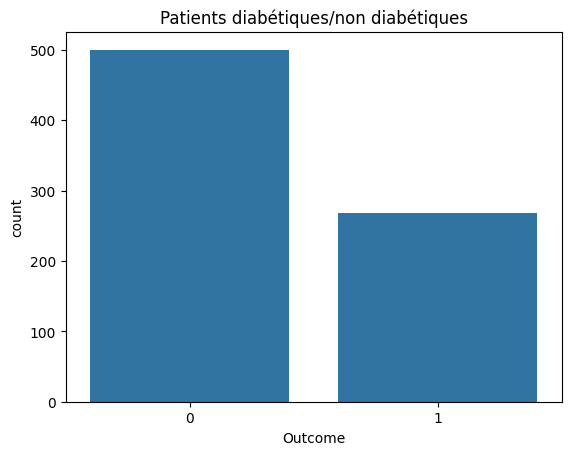

In [ ]:
sns.countplot(

x='Outcome',
data=df

)

plt.title(
"Patients diabétiques/non diabétiques"
)

plt.show()

## Visualisation (EDA)

Histogramme Glucose

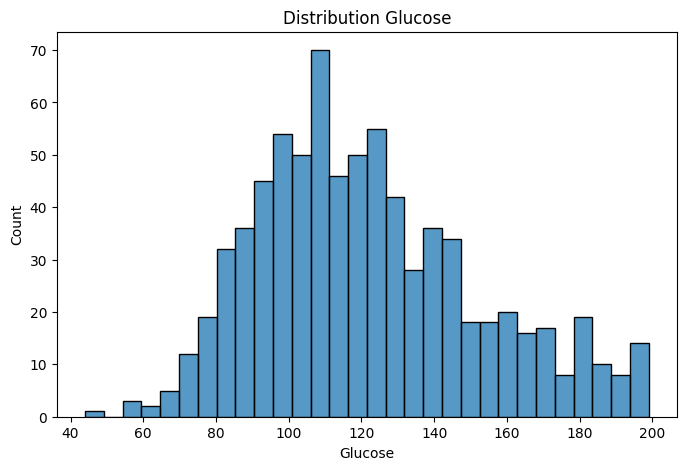

In [ ]:
plt.figure(
figsize=(8,5)
)

sns.histplot(
df['Glucose'],
bins=30
)

plt.title(
"Distribution Glucose"
)

plt.show()

Heatmap

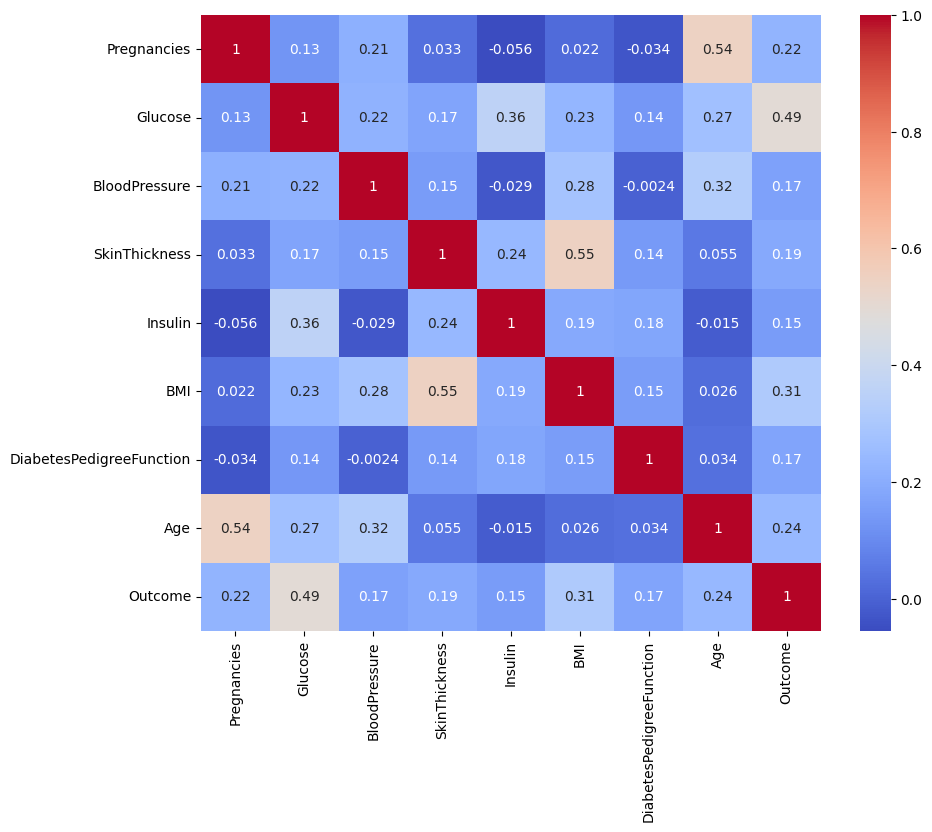

In [ ]:
plt.figure(
figsize=(10,8)
)

sns.heatmap(

df.corr(),
annot=True,
cmap='coolwarm'

)

plt.show()

Boxplot BMI

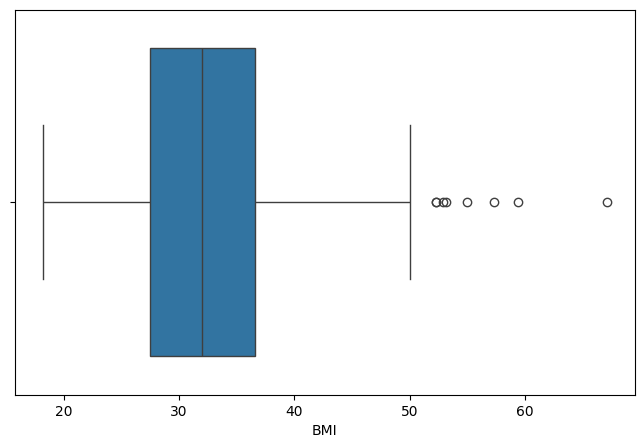

In [ ]:
plt.figure(
figsize=(8,5)
)

sns.boxplot(
x=df['BMI']
)

plt.show()

# PARTIE II — IA AVANCÉE (ANN)

Séparer X et y

In [ ]:
X=df.drop(
'Outcome',
axis=1
)

y=df['Outcome']

Train/Test Split

In [ ]:
X_train,X_test,y_train,y_test= train_test_split(

X,
y,

test_size=0.2,

random_state=42

)

StandardScaler

In [ ]:
scaler=StandardScaler()

X_train=scaler.fit_transform(
X_train
)

X_test=scaler.transform(
X_test
)

# Création du modèle ANN

In [ ]:
model=Sequential()

model.add(
Dense(
64,
activation='relu'
)
)

model.add(
Dense(
32,
activation='relu'
)
)

model.add(
Dense(
16,
activation='relu'
)
)

model.add(
Dense(
1,
activation='sigmoid'
)
)

Compilation modèle

In [ ]:
model.compile(

optimizer='adam',

loss='binary_crossentropy',

metrics=['accuracy']

)

# Entraînement ANN

In [ ]:
history=model.fit(

X_train,
y_train,

epochs=50,

batch_size=32,

validation_split=0.2

)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6171 - loss: 0.6667 - val_accuracy: 0.6992 - val_loss: 0.6299
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7719 - loss: 0.5777 - val_accuracy: 0.7154 - val_loss: 0.5657
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7739 - loss: 0.5114 - val_accuracy: 0.7154 - val_loss: 0.5266
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7739 - loss: 0.4709 - val_accuracy: 0.7317 - val_loss: 0.4963
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7739 - loss: 0.4543 - val_accuracy: 0.7480 - val_loss: 0.4839
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7862 - loss: 0.4385 - val_accuracy: 0.7561 - val_loss: 0.4800
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7923 - loss: 0.4278 - val_accuracy: 0.7642 - val_loss: 0.4738
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7963 - loss: 0.4169 - val_accuracy: 0.7480 - val_loss

# Prédictions

In [ ]:
pred=model.predict(
X_test
)

pred=(pred>0.5).astype(int)

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


# Accuracy

In [ ]:
print(

accuracy_score(
y_test,
pred
)

)

0.7272727272727273


# Classification Report

In [ ]:
print(

classification_report(

y_test,
pred

)

)

              precision    recall  f1-score   support

           0       0.83      0.73      0.77        99
           1       0.60      0.73      0.66        55

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154



# Confusion Matrix

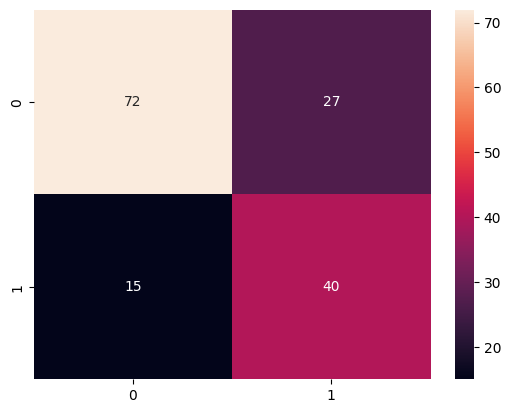

In [ ]:
cm=confusion_matrix(

y_test,
pred

)

sns.heatmap(

cm,
annot=True,
fmt='d'

)

plt.show()

# Accuracy Graph

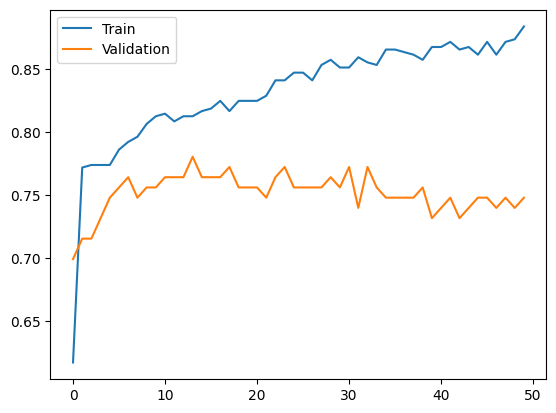

In [ ]:
plt.plot(
history.history['accuracy']
)

plt.plot(
history.history['val_accuracy']
)

plt.legend([
'Train',
'Validation'
])

plt.show()

#Loss Graphs

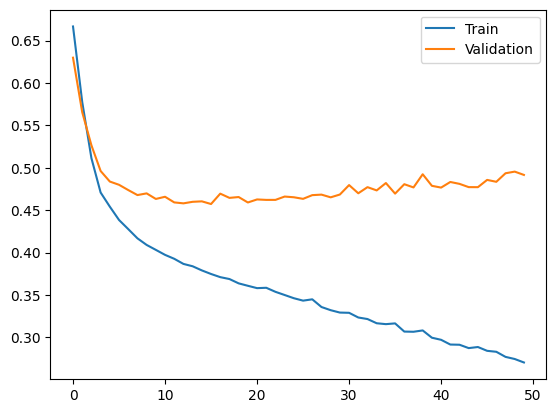

In [ ]:
plt.plot(
history.history['loss']
)

plt.plot(
history.history['val_loss']
)

plt.legend([
'Train',
'Validation'
])

plt.show()

# Decision Layer

In [ ]:
def diabetes_decision(score):

    if score<0.3:

        return "Low Risk"

    elif score<0.7:

        return "Medium Risk"

    else:

        return "High Risk"


score=0.82

print(

diabetes_decision(
score
)

)

High Risk


# Sauvegarder l'historique du modèle

In [ ]:
history_df=pd.DataFrame(

history.history

)

history_df.to_csv(

"training_history.csv",

index=False

)

# Sauvegarde du modèle

In [ ]:
pickle.dump(

scaler,

open(
'scaler.pkl',
'wb'
)

)

model.save(

'diabetes_model.keras'

)

df.to_csv(

'diabetes_cleaned.csv',

index=False

)

history_df=pd.DataFrame(

history.history

)

history_df.to_csv(

'training_history.csv',

index=False

)

print(
"Tous les fichiers sauvegardés"
)

Tous les fichiers sauvegardés
